In [1]:
import pandas as pd
import torch_geometric
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pickle
import numpy as np
import sys
import copy

Processing steps:

- renamed patients in mathylation and label df (removed .01 all had at the end)
- drop nans for mathylation and expression data, i.e. remove genes with at least one missing value 
- find patients and genes overlap and reduce methylation, expression and label df to this
- convert label in lable df to binary (luminal A vs. others)

- Download whole IID PPI for human, filter for (breast) cancer, experimental 

In [2]:
# Load data BCS (breast cancer subtypes)
bcs_expression = pd.read_csv('BC_SUBTYPES_normalized_rnaseq_data.tsv', sep='\t')
bcs_methylation = pd.read_csv('Methylation_Firehose.cct', sep='\t')
bcs_labels = pd.read_csv('label_info.txt', sep='\t', header=None, names=['patient', 'label'])

In [3]:
# Labels
# Overview labels
bcs_labels['label'].value_counts()

label
2    499
3    197
0    171
1     78
4     36
Name: count, dtype: int64

In [4]:
# Set binary label (for luminal A)
bcs_labels['binary luminal-A'] = (bcs_labels['label'] == 2).astype(int)

In [5]:
# All patients in labels with .01 found!
print('Patients with expression data without .01 at end: ')
for patient in bcs_labels['patient']:
    if patient[-3:] != '.01':
        print(patient)

Patients with expression data without .01 at end: 


In [6]:
# Remove .01 at the end
bcs_labels['patient'] = bcs_labels['patient'].str[:-3]

In [7]:
# Expression and methylation data
# Remove rows (=genes) with at least one nan
bcs_expression.dropna(axis='index', ignore_index=True, inplace=True)
bcs_methylation.dropna(axis='index', ignore_index=True, inplace=True)

In [8]:
# Match patients
print('Patients with methylation data', bcs_methylation.columns[1:])
print('Number patients with methylation data', bcs_methylation.shape[1]-1)
print('Number gens with methylation data', bcs_methylation.shape[0], '\n')

print('Patients with expression data', bcs_expression.columns[1:])
print('Patients with expression data', bcs_expression.shape[1]-1)
print('Patients with expression data', bcs_expression.shape[0], '\n')

Patients with methylation data Index(['TCGA.3C.AAAU', 'TCGA.3C.AALI', 'TCGA.3C.AALJ', 'TCGA.3C.AALK',
       'TCGA.4H.AAAK', 'TCGA.5L.AAT0', 'TCGA.5L.AAT1', 'TCGA.5T.A9QA',
       'TCGA.A1.A0SB', 'TCGA.A1.A0SE',
       ...
       'TCGA.UL.AAZ6', 'TCGA.UU.A93S', 'TCGA.V7.A7HQ', 'TCGA.W8.A86G',
       'TCGA.WT.AB41', 'TCGA.WT.AB44', 'TCGA.XX.A899', 'TCGA.XX.A89A',
       'TCGA.Z7.A8R5', 'TCGA.Z7.A8R6'],
      dtype='object', length=783)
Number patients with methylation data 783
Number gens with methylation data 17908 

Patients with expression data Index(['TCGA.3C.AAAU.01', 'TCGA.3C.AALI.01', 'TCGA.3C.AALJ.01',
       'TCGA.3C.AALK.01', 'TCGA.4H.AAAK.01', 'TCGA.5L.AAT0.01',
       'TCGA.5T.A9QA.01', 'TCGA.A1.A0SB.01', 'TCGA.A1.A0SD.01',
       'TCGA.A1.A0SE.01',
       ...
       'TCGA.UL.AAZ6.01', 'TCGA.UU.A93S.01', 'TCGA.V7.A7HQ.01',
       'TCGA.W8.A86G.01', 'TCGA.WT.AB41.01', 'TCGA.WT.AB44.01',
       'TCGA.XX.A899.01', 'TCGA.XX.A89A.01', 'TCGA.Z7.A8R5.01',
       'TCGA.Z7.A8R6.01'],

In [9]:
# All patients in expression data with .01 found!
print('Patients with expression data without .01 at end: ')
for patient in bcs_expression.columns[1:]:
    if patient[-3:] != '.01':
        print(patient)


Patients with expression data without .01 at end: 


In [10]:
# Remove .01 for matching
reduced_columns = dict()
for column in list(bcs_expression.columns[1:]):
    reduced_columns[column]=column[:-3]

bcs_expression.rename(columns=reduced_columns, inplace=True)

In [11]:
# Match patients
bcs_methyl_genes = set(bcs_methylation['attrib_name'])
bcs_methyl_patients = set(bcs_methylation.columns[1:])
bcs_expr_genes = set(bcs_expression['probe'])
bcs_expr_patients = set(bcs_expression.columns[1:])

matched_genes = bcs_methyl_genes.intersection(bcs_expr_genes)
matched_patients =  bcs_methyl_patients.intersection(bcs_expr_patients)

print('Gene match: ', matched_genes)
print('Number gene match: ', len(matched_genes))
print('Patient match: ', matched_patients)
print('Number patient match: ', len(matched_patients))

Gene match:  {'ECE2', 'ENTPD6', 'CCL13', 'LRRC34', 'ZNF212', 'GINS4', 'SPTLC1', 'STAC', 'CRYBA2', 'UCHL3', 'ALX4', 'PRDM16', 'YTHDC2', 'NUBPL', 'POLH', 'ULBP2', 'TOX4', 'MYCN', 'EXOSC10', 'LDHC', 'SPNS1', 'PEG3', 'POLD2', 'SIAH2', 'LRRC57', 'ACER3', 'RYBP', 'PIK3R6', 'MRC2', 'PCDH18', 'SPATS1', 'DGCR5', 'EFNA5', 'ARMC3', 'CDYL', 'EXOC8', 'IQGAP3', 'CABP1', 'PUS10', 'C8orf37', 'TMED4', 'ZBTB7C', 'SEC14L4', 'EPS15', 'EPS8L2', 'MLST8', 'INSL3', 'STK16', 'IGFBP5', 'OR4D10', 'FMOD', 'RORC', 'ZNF438', 'SNORA52', 'ARHGEF19', 'ASB5', 'CYP24A1', 'SEC14L1', 'ARID3C', 'MAD2L1BP', 'NAA40', 'EPO', 'ZBTB46', 'IRX2', 'UPP2', 'PIWIL4', 'GIMAP7', 'ZNF765', 'SH2B3', 'VAPB', 'IMPACT', 'TBC1D7', 'KLF14', 'RERE', 'ZC3HAV1L', 'RAD51', 'NAA20', 'ZNF787', 'WDR41', 'PAEP', 'PTX3', 'EEF1A2', 'EFCAB5', 'SLC46A1', 'ELMOD2', 'PITPNM2', 'ASL', 'HLCS', 'PARD6A', 'ARPC4', 'TADA1', 'CRISPLD1', 'IARS2', 'C6orf223', 'GINS2', 'PM20D1', 'SPINT1', 'WIZ', 'BAIAP2L1', 'LILRA2', 'RTEL1', 'GIMAP2', 'KLF11', 'PON1', 'HIRIP3', '

In [12]:
# Reduce dataframe to matched genes and patients
bcs_methylation_matched = bcs_methylation[bcs_methylation['attrib_name'].isin(matched_genes)][['attrib_name'] + list(matched_patients)]
bcs_expression_matched = bcs_expression[bcs_expression['probe'].isin(matched_genes)][['probe'] + list(matched_patients)]

bcs_labels_matched = bcs_labels[bcs_labels['patient'].isin(matched_patients)]
bcs_labels_matched = bcs_labels_matched[['patient', 'binary luminal-A']]
bcs_labels_matched.rename(columns={'binary luminal-A':'binary label'}, inplace=True)


bcs_methylation_matched.reset_index(inplace=True, drop=True)
bcs_expression_matched.reset_index(inplace=True, drop=True)
bcs_labels_matched.reset_index(inplace=True, drop=True)

In [13]:
# Store matched gene list to upload on IID
with open('matched_genes_expr_methyl.txt', 'w+') as f:
    for items in matched_genes:
        f.write('%s\n' %items)

In [14]:
bcs_labels_matched['binary label'].value_counts()

binary label
1    360
0    329
Name: count, dtype: int64

In [15]:
bcs_labels_matched.set_index('patient', inplace=True)
bcs_labels_matched.sort_index(axis=0)
bcs_labels_matched

,binary label
patient,
TCGA.3C.AAAU,1
TCGA.3C.AALI,0
TCGA.3C.AALJ,0
TCGA.3C.AALK,1
TCGA.4H.AAAK,1
...,...
TCGA.WT.AB44,1
TCGA.XX.A899,1
TCGA.XX.A89A,1


In [16]:
# Set gene name as index
bcs_methylation_matched.set_index('attrib_name', inplace=True)
bcs_expression_matched.set_index('probe', inplace=True)
bcs_methylation_matched.sort_index(axis=0, inplace=True)
bcs_methylation_matched.sort_index(axis=1, inplace=True)
bcs_expression_matched.sort_index(axis=0, inplace=True)
bcs_expression_matched.sort_index(axis=1, inplace=True)

In [17]:
bcs_expression_matched

,TCGA.3C.AAAU,TCGA.3C.AALI,TCGA.3C.AALJ,TCGA.3C.AALK,TCGA.4H.AAAK,TCGA.5L.AAT0,TCGA.5T.A9QA,TCGA.A1.A0SB,TCGA.A1.A0SE,TCGA.A1.A0SF,...,TCGA.UL.AAZ6,TCGA.UU.A93S,TCGA.V7.A7HQ,TCGA.W8.A86G,TCGA.WT.AB41,TCGA.WT.AB44,TCGA.XX.A899,TCGA.XX.A89A,TCGA.Z7.A8R5,TCGA.Z7.A8R6
probe,,,,,,,,,,,,,,,,,,,,,
A1BG,3.694557,3.867356,4.668282,3.546835,4.054780,3.633608,4.527529,2.018976,3.605626,4.298500,...,1.887987,4.530535,5.945513,4.983264,3.045245,4.922152,3.730521,3.932620,4.652885,4.010933
A1CF,0.000000,0.000000,0.031098,0.000000,0.014774,0.000000,0.021898,0.000000,0.000000,0.000000,...,0.014598,0.000000,0.000000,0.016293,0.000000,0.000000,0.000000,0.077256,0.000000,0.000000
A2M,7.803951,8.105748,8.339603,8.604093,8.465314,8.775113,7.154383,10.279843,9.174619,9.144944,...,7.498456,7.271065,8.230628,9.382682,8.524383,7.741468,9.470063,9.243611,10.324730,8.149115
A2ML1,0.065848,0.188047,0.000000,0.072780,0.151224,0.052020,0.000000,0.149721,0.045398,0.150202,...,2.563986,0.000000,0.609415,0.064500,0.000000,0.294584,0.017348,1.455325,0.102164,0.191686
A4GALT,2.567137,3.555167,5.337860,5.118567,4.624558,4.682870,5.146602,4.696834,4.275876,4.959096,...,5.282695,2.620222,6.696409,4.321961,7.191697,4.777695,5.091777,5.392195,4.948054,5.826384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,5.803627,5.425242,4.655976,4.774629,5.099053,5.133085,5.001013,5.612987,5.053694,5.084517,...,5.547677,5.130438,4.359139,4.939622,4.012477,4.767544,5.285375,5.425547,4.636752,5.022146
ZYG11A,3.842903,3.417309,4.113984,3.226726,0.761244,0.811991,0.170135,1.017272,1.942230,2.490831,...,2.277769,0.746185,1.586569,2.701931,1.765682,2.637694,0.997042,3.142878,1.779546,3.042476
ZYG11B,5.197545,4.157457,3.997121,4.134195,4.521068,4.177709,3.585882,5.401382,4.813824,4.678251,...,3.949441,4.301524,3.572331,3.995697,2.971213,3.400025,4.281008,4.416539,3.862979,4.171357


In [18]:
bcs_methylation_matched

,TCGA.3C.AAAU,TCGA.3C.AALI,TCGA.3C.AALJ,TCGA.3C.AALK,TCGA.4H.AAAK,TCGA.5L.AAT0,TCGA.5T.A9QA,TCGA.A1.A0SB,TCGA.A1.A0SE,TCGA.A1.A0SF,...,TCGA.UL.AAZ6,TCGA.UU.A93S,TCGA.V7.A7HQ,TCGA.W8.A86G,TCGA.WT.AB41,TCGA.WT.AB44,TCGA.XX.A899,TCGA.XX.A89A,TCGA.Z7.A8R5,TCGA.Z7.A8R6
attrib_name,,,,,,,,,,,,,,,,,,,,,
A1BG,-0.4189,-0.4445,-0.4530,-0.3371,-0.3168,-0.4216,-0.4501,-0.4266,-0.4394,-0.4554,...,0.1149,-0.4359,-0.4449,-0.4536,-0.3333,-0.4519,-0.4570,-0.4532,-0.4466,-0.4712
A1CF,-0.1314,-0.0289,0.1251,0.2255,0.2011,0.1854,0.0005,0.3754,0.2281,0.1910,...,-0.1117,-0.1708,0.1882,0.3039,0.0850,0.3127,0.3024,0.1636,0.2753,-0.2305
A2M,0.4395,0.2832,0.4352,0.4009,0.4106,0.2667,0.4451,0.3912,0.2079,0.1134,...,0.4617,-0.0116,0.4282,0.2922,0.4357,0.4254,0.3826,-0.1324,0.2512,0.3634
A2ML1,0.4139,0.4256,0.4379,0.3787,0.3668,0.4236,0.4206,0.0913,0.3338,0.3257,...,0.4336,0.0518,0.3171,0.2859,0.4315,0.3802,0.3814,0.1136,0.2718,0.3073
A4GALT,0.2570,0.1546,-0.0647,0.1057,0.0568,0.1510,-0.0958,0.0134,0.1221,-0.0229,...,0.0206,0.1855,-0.2351,0.2120,-0.2748,0.1933,0.0342,-0.0687,0.0737,-0.2856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,-0.4498,-0.4481,-0.4317,-0.4537,-0.4510,-0.4476,-0.4373,-0.4812,-0.4712,-0.4696,...,-0.4550,-0.4392,-0.4641,-0.4732,-0.4337,-0.4486,-0.4734,-0.4696,-0.4395,-0.4714
ZYG11A,-0.2256,0.2165,0.1322,0.2979,0.0416,0.1487,0.4260,-0.2479,-0.0319,-0.0813,...,0.2507,-0.0274,-0.0645,-0.1130,0.1542,0.1084,0.0741,0.0176,0.3058,0.1380
ZYG11B,-0.3629,-0.3602,-0.3283,-0.3847,-0.4026,-0.4008,-0.3616,-0.4689,-0.4696,-0.4775,...,-0.3759,-0.3213,-0.4746,-0.4674,-0.3734,-0.3674,-0.4644,-0.4624,-0.3142,-0.4740


In [19]:
# IID PPI (already matched with genes and only cancer-relevant)
##################################################################

In [20]:
PPI_extended = pd.read_csv('Human_annotated_PPIs.txt', sep="\t")

C:\Users\schirmacher3\AppData\Local\Temp\ipykernel_26928\3651276777.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  PPI_extended = pd.read_csv('Human_annotated_PPIs.txt', sep="\t")


In [21]:
PPI = PPI_extended[['symbol1', 'symbol2', 'evidence_type', 'cancer', 'breast_cancer', 'n_exp_pmids']]

In [22]:
PPI

,symbol1,symbol2,evidence_type,cancer,breast_cancer,n_exp_pmids
0,MAP2K4,FLNC,exp|pred,2,1,1
1,ACTN2,MYPN,exp,0,0,1
2,FNTA,ACVR1,exp,1,1,1
3,GATA2,PML,exp,2,2,1
4,RPA2,STAT3,exp|pred,2,2,3
...,...,...,...,...,...,...
1675922,BMP1,DSPP,ortho,2,0,1
1675923,SNAI1,LOXL1,ortho,2,2,1
1675924,FBLN1,COL18A1,ortho,2,2,1
1675925,COMP,COMP,ortho,2,2,1


<Axes: xlabel='n_exp_pmids'>

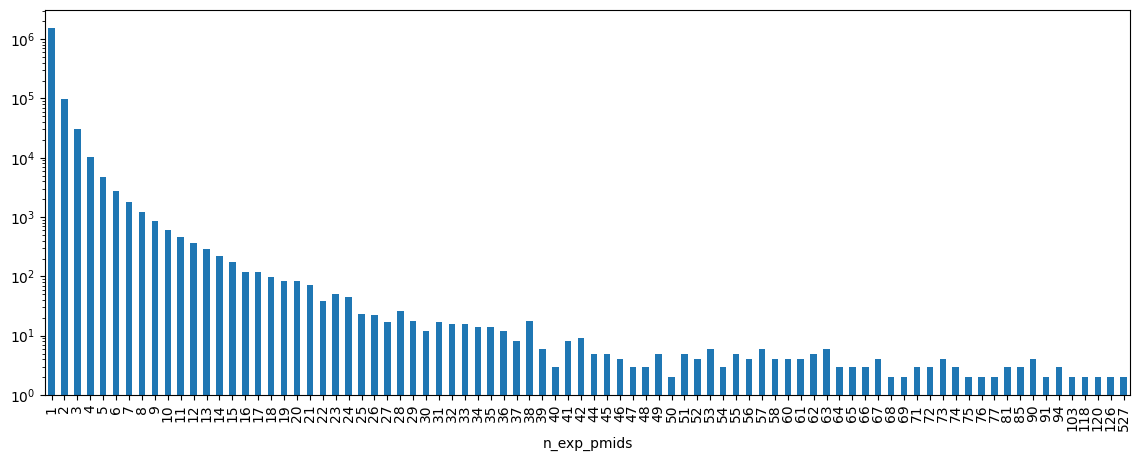

In [23]:
PPI['n_exp_pmids'].value_counts().sort_index().plot.bar(log=True, figsize=(14,5))


In [24]:
PPI_exp = PPI[PPI['evidence_type'].str.contains('exp')]

In [25]:
PPI_matched = PPI_exp[PPI_exp['symbol1'].isin(matched_genes) & PPI_exp['symbol2'].isin(matched_genes)]

In [26]:
# Choose disease (cancer) and number of experiemts (>=2)
breast_cancer = PPI_matched[PPI_matched['breast_cancer']==2]
PPI_bc =  breast_cancer[breast_cancer['n_exp_pmids']>=3]

In [27]:
any(PPI_bc[['symbol1', 'symbol2']].duplicated())

False

In [28]:
edges = set(zip(PPI_bc['symbol1'], PPI_bc['symbol2']))
sum_reverse = sum(((s2, s1) in edges) for s1, s2 in edges)
print(sum_reverse)

622


In [29]:
counter = 0

for index, row in PPI_bc.iterrows():
    symbol1 = row['symbol1']
    symbol2 = row['symbol2']
    reverse_pair = (symbol2, symbol1)
    
    if reverse_pair in edges:
        print("Same edge in different direction found!")
        rows = PPI_bc[(PPI_bc['symbol1'] == reverse_pair[1]) & (PPI_bc['symbol2'] == reverse_pair[0])]
        print(rows)
        reverse_rows = PPI_bc[(PPI_bc['symbol1'] == reverse_pair[0]) & (PPI_bc['symbol2'] == reverse_pair[1])]
        print(reverse_rows)
        if symbol1 != symbol2:
            counter += 1

print("Double edges that are not self-directed: ", counter)

Same edge in different direction found!
   symbol1 symbol2 evidence_type  cancer  breast_cancer  n_exp_pmids
42    MCM2    MCM2     exp|ortho       2              2            3
   symbol1 symbol2 evidence_type  cancer  breast_cancer  n_exp_pmids
42    MCM2    MCM2     exp|ortho       2              2            3
Same edge in different direction found!
    symbol1 symbol2 evidence_type  cancer  breast_cancer  n_exp_pmids
235    PKD2    PKD2           exp       2              2            7
    symbol1 symbol2 evidence_type  cancer  breast_cancer  n_exp_pmids
235    PKD2    PKD2           exp       2              2            7
Same edge in different direction found!
    symbol1 symbol2 evidence_type  cancer  breast_cancer  n_exp_pmids
289     CLU     CLU           exp       2              2            3
    symbol1 symbol2 evidence_type  cancer  breast_cancer  n_exp_pmids
289     CLU     CLU           exp       2              2            3
Same edge in different direction found!
    

In [30]:
# select edges and remove self-loops
edges_processed = PPI_bc[['symbol1', 'symbol2']][PPI_bc['symbol1']!=PPI_bc['symbol2']]
print('Number edges without self-loops: ', len(edges_processed))

Number edges without self-loops:  6496


In [31]:
#Nodes
nodes = list(set(edges_processed['symbol1'].unique()) | set(edges_processed['symbol2'].unique()))
node_index = {node: idx for idx, node in enumerate(nodes)}
print('Number of nodes:', len(nodes))
print('Nodes: ', node_index)

Number of nodes: 1917
Nodes:  {'MCM2': 0, 'DAPK1': 1, 'GIT1': 2, 'PARP2': 3, 'RUNX3': 4, 'PABPC1': 5, 'RPSA': 6, 'SMURF1': 7, 'TTK': 8, 'MYBBP1A': 9, 'TNS3': 10, 'SIAH2': 11, 'DCLK1': 12, 'MRPS23': 13, 'KCNH1': 14, 'NOS3': 15, 'EFNA5': 16, 'IQGAP3': 17, 'BRD8': 18, 'RPS6KA1': 19, 'FECH': 20, 'EPS15': 21, 'NR1H4': 22, 'IGFBP5': 23, 'BLM': 24, 'E2F5': 25, 'BDNF': 26, 'ZC3H11A': 27, 'RAB1B': 28, 'HSPG2': 29, 'REST': 30, 'SMYD3': 31, 'EPO': 32, 'MUC1': 33, 'VASP': 34, 'ROPN1L': 35, 'LOXL1': 36, 'SH2B3': 37, 'HMMR': 38, 'RNF11': 39, 'ITGA5': 40, 'RAD51': 41, 'MCC': 42, 'PTX3': 43, 'HLA-A': 44, 'EEF1A2': 45, 'PSMD3': 46, 'SIX3': 47, 'ANKRD44': 48, 'SEMA4D': 49, 'NIN': 50, 'GINS2': 51, 'INCENP': 52, 'CD80': 53, 'RTEL1': 54, 'PLCB1': 55, 'MAK16': 56, 'MYH9': 57, 'RB1CC1': 58, 'PPARG': 59, 'SLC1A5': 60, 'FOSL1': 61, 'EPAS1': 62, 'UBR5': 63, 'APBB1': 64, 'WASF1': 65, 'CXCL1': 66, 'FOXO1': 67, 'POTEF': 68, 'TNC': 69, 'CD14': 70, 'APPL2': 71, 'IL2RA': 72, 'VTA1': 73, 'S100A7': 74, 'CCND2': 75, 'P2

In [32]:
edge_index = []
for _, row in edges_processed.iterrows():
    symbol_1 = row['symbol1']
    symbol_2 = row['symbol2']
    edge_index.append([node_index[symbol_1], node_index[symbol_2]])

edge_index = torch.tensor(edge_index).t()

In [33]:
# Graph construction
graph_prelim = Data(edge_index=edge_index, num_nodes = len(nodes))

In [34]:
from torch_geometric.transforms import LargestConnectedComponents

transform = LargestConnectedComponents()
main_component = transform(graph_prelim)

In [35]:
main_component

Data(edge_index=[2, 6448], num_nodes=1836)

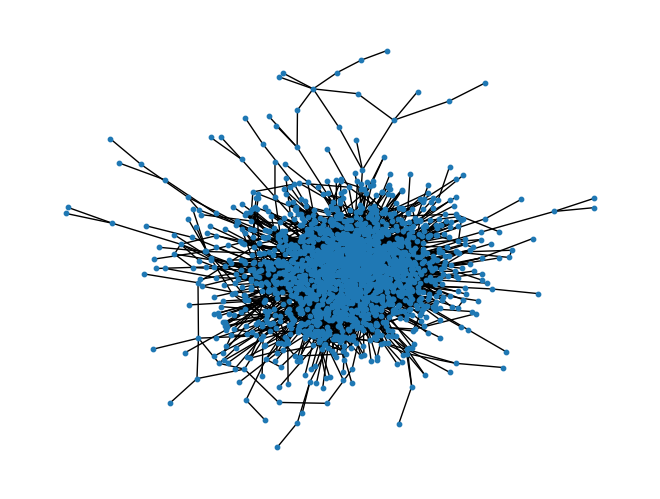

In [36]:
#Quick plausability check 
import networkx as nx

m = torch_geometric.utils.to_networkx(main_component, to_undirected=True, )
nx.draw(m, node_size=10)

In [37]:
graph_prelim

Data(edge_index=[2, 6496], num_nodes=1917)

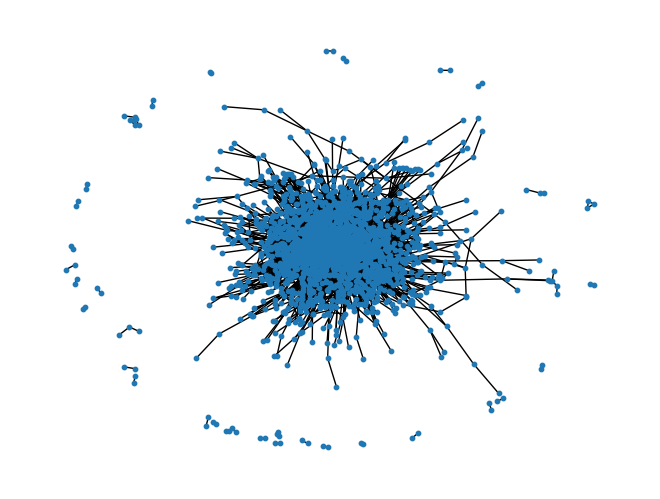

In [38]:
g = torch_geometric.utils.to_networkx(graph_prelim, to_undirected=True)
nx.draw(g, node_size=10)

In [39]:
# Graph information
main_component.is_directed()

True

In [40]:
main_component.has_self_loops()

False

In [41]:
list_of_graphs = []

for patient in matched_patients:
    expr = bcs_expression_matched[patient]
    methyl = bcs_methylation_matched[patient]

    feature_array = torch.zeros((len(node_index),2))
    
    for node, idx in node_index.items():
        feature_array[idx,0] = expr[node]
        feature_array[idx,1] = methyl[node]

    graph = copy.deepcopy(main_component)
    graph.x = feature_array.clone()
    graph.y = torch.tensor([bcs_labels_matched.loc[patient]['binary label']], dtype=torch.float32)
    list_of_graphs.append(graph)

In [42]:
#Checks
list_of_graphs[0].x

tensor([[ 7.5278,  0.1989],
        [ 4.5262, -0.3388],
        [ 6.2485,  0.3546],
        ...,
        [ 2.2663, -0.4772],
        [ 4.2106,  0.3799],
        [ 5.5898,  0.2405]])

In [43]:
list_of_graphs[0].y

tensor([0.])

In [44]:
#Normalization, copied from preprocessing KIRC (KIRC_preprocessing/Data_preprocessing.ipynb) [with min/max tensor set right to all]

# First transformations & min/max finding
x_max_expr_all = sys.float_info.min
x_max_methyl_all = sys.float_info.min
x_min_expr_all = sys.float_info.max
x_min_methyl_all = sys.float_info.max

# First transformations & min/max finding
for graph in list_of_graphs:
    graph.y = graph.y.to(torch.float32)
    graph.edge_index = torch_geometric.utils.to_undirected(graph.edge_index)
    graph.edge_index = torch_geometric.utils.sort_edge_index(graph.edge_index)
    graph.edge_index = graph.edge_index.to(torch.long)
    del graph.num_nodes

    x_max_expr, x_max_methyl = torch.amax(graph.x, dim=0).tolist()
    x_min_expr, x_min_methyl = torch.amin(graph.x, dim=0).tolist()

    if x_max_expr_all < x_max_expr:
        x_max_expr_all = x_max_expr

    if x_min_expr_all > x_min_expr:
        x_min_expr_all = x_min_expr

    if x_max_methyl_all < x_max_methyl:
        x_max_methyl_all = x_max_methyl

    if x_min_methyl_all > x_min_methyl:
        x_min_methyl_all = x_min_methyl

max_tensor_all = torch.tensor([x_max_expr_all, x_max_methyl_all])
min_tensor_all = torch.tensor([x_min_expr_all, x_min_methyl_all])

# Normalize
for graph in list_of_graphs:
    graph.x = (graph.x - min_tensor_all) / (max_tensor_all - min_tensor_all)


with open('../brca_graphs_preprocessed_all.pkl', "wb") as f:
    pickle.dump(list_of_graphs, f)

In [45]:
#Get expression data (mRNA) and store (same as for KIRC)
data_expr = [list_of_graphs[i].clone() for i in range(len(list_of_graphs))]
for i in range(len(data_expr)):
    data_expr[i].x = list_of_graphs[i].x[:,0].unsqueeze(1) 

with open('../brca_graphs_preprocessed_expr.pkl', "wb") as f:
    pickle.dump(data_expr, f)

In [46]:
#Get expression data (mRNA) and store (same as for KIRC)
data_methyl = [list_of_graphs[i].clone() for i in range(len(list_of_graphs))]
for i in range(len(data_methyl)):
    data_methyl[i].x = list_of_graphs[i].x[:,1].unsqueeze(1) 

with open('../brca_graphs_preprocessed_methyl.pkl', "wb") as f:
    pickle.dump(data_methyl, f)